# Testing sensitivities of different scintillators

In this notebook I test the sensitivities of the three different scintillators available in the laboratory. Each scintillator was exposed for 500ms with different intensities detailed in the table below. In each case the current is the maximum value the source allows for the given voltage.

| Voltage <br> (kV) | Current <br> ($\mu$A) |
|--------:|--------:|
|60       |134      |
|70       |115      |
|80       |100      |
|100      |80       |


For each scintillator I took 5 images. I get the mean of all the images at each voltage.

Potentially, the analysis could be improved if the average was only performed over the area exposed to the light cone, but since evey image is taken in the same conditions, this will probably not affect the general behavior.

It would be convenient to perform the same analysis with new images taken with longer exposure, and/or saving image as a 16-bit tiff, rather than 8-bit tiff.


In [41]:
import sys
sys.path.append('..')
from core.log_utils import no_op
from imaging.img_utils import *
from typing import Union
import matplotlib.pyplot as plt

LABIMG_DIR = '../data/lab_images/'
FLATS_DIR = LABIMG_DIR+'flatframes/'
DARKS_DIR = LABIMG_DIR+'darkframes/'
SCINT_DIR = LABIMG_DIR+'test_scintillators/'

#Import scintillator images
scint_names = ['scintillator'+str(i) for i in range(1,4)]
voltages = [60, 70, 80, 100]
scint_imgs = {scint: {voltage: import_images(SCINT_DIR+scint+'/ni500ms_'+str(voltage)+'*',log_fn=print) for voltage in voltages}for scint in scint_names}


Imported 5 image(s)
Imported 5 image(s)
Imported 5 image(s)
Imported 5 image(s)
Imported 5 image(s)
Imported 5 image(s)
Imported 5 image(s)
Imported 5 image(s)
Imported 5 image(s)
Imported 5 image(s)
Imported 5 image(s)
Imported 5 image(s)


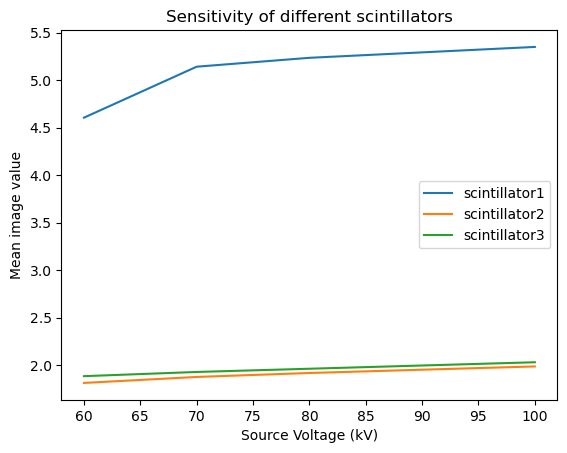

In [85]:
[plt.plot(list(scint_means[scint].keys()), list(scint_means[scint].values()),label=scint) for scint in scint_means.keys()]
plt.xlabel('Source Voltage (kV)')
plt.ylabel('Mean image value')
plt.title('Sensitivity of different scintillators')
plt.legend()
plt.show()

The sensitivity of all three scintillators increased with the voltage, even when the maximum current the source allowed is smaller for larger voltages. By far, the most sensitive scintillator is "scintillator1", which is the one we have been using so far in the experimental setting.

In [86]:
!export PATH=/Library/TeX/texbin:$PATH